# Лабораторная работа №3
## Вариант 3.2
#### Выполнили: Аверьянова Мария, Калягин Дмитрий, Кашникова Анна, Климович Анна


## Исходная задача

Рассмотрим задачу минимизации:

$$
\begin{aligned}
\text{minimize} \quad & f(x) = \sum_{i=1}^n x_i \log x_i \\
\text{subject to} \quad & Ax = b
\end{aligned}
$$

где $x \in \mathbb{R}^n$, $A \in \mathbb{R}^{p \times n}$, $b \in \mathbb{R}^p$, $p < n$.



## 1. Исследование на выпуклость

Целевая функция $f(x)$ является суммой функций вида $h(u) = u \log u$. Исследуем выпуклость этой функции на области $x_i > 0$:

$$
h''(u) = \frac{d^2}{du^2}(u \log u) = \frac{d}{du}(1 + \log u) = \frac{1}{u}
$$

Так как $\frac{1}{u} > 0$ для всех $u > 0$, функция $u \log u$ строго выпукла.
Сумма строго выпуклых функций также строго выпукла, поэтому $f(x)$ строго выпукла на области $x_i > 0$.

Ограничения $Ax = b$ задают аффинное множество, которое является выпуклым.

Поэтому исходная задача — выпуклая.



## Формулировка двойственной задачи

Запишем лагранжиан задачи:

$$
L(x, \lambda) = \sum_{i=1}^n x_i \log x_i + \lambda^T(Ax - b)
$$

Для нахождения двойственной функции $q(\lambda) = \inf_x L(x, \lambda)$ приравняем частную производную по каждому $x_i$ к нулю:

$$
\frac{\partial L}{\partial x_i} = \log x_i + 1 + a_i^T \lambda = 0
$$

Отсюда находим оптимальное $x^*$, выраженное через $\lambda$:

$$
\log x_i^*(\lambda) = -1 - a_i^T \lambda \quad \Rightarrow \quad x_i^*(\lambda) = \exp(-1 - a_i^T \lambda)
$$

Подставим $x^*(\lambda)$ обратно в лагранжиан:

$$
\begin{aligned}
q(\lambda) &= L(x^*(\lambda), \lambda) \\
&= \sum_{i=1}^n x_i^* \log x_i^* + \lambda^T A x^* - \lambda^T b \\
&= \sum_{i=1}^n x_i^* (-1 - a_i^T \lambda) + \sum_{i=1}^n x_i^* (a_i^T \lambda) - b^T \lambda \\
&= \sum_{i=1}^n (-x_i^*) - b^T \lambda \\
&= -\sum_{i=1}^n \exp(-1 - a_i^T \lambda) - b^T \lambda
\end{aligned}
$$

Таким образом, двойственная функция имеет вид:

$$
q(\lambda) = -b^T \lambda - \sum_{i=1}^n \exp(-1 - a_i^T \lambda)
$$

Двойственная задача заключается в максимизации этой функции:

$$
\max_{\lambda \in \mathbb{R}^p} \quad q(\lambda)
$$

Или в форме минимизации:

$$
\text{minimize} \quad b^T \lambda + \sum_{i=1}^n \exp(-1 - a_i^T \lambda)
$$

# 2. Генерация тестовых примеров и эталонное решение через CVXPY

In [228]:
import time
import pickle
import matplotlib.pyplot as plt

import numpy as np
import cvxpy as cp
import pandas as pd

from pathlib import Path
from scipy.linalg import svd
from scipy.optimize import minimize_scalar
from typing import List, Dict



ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ



In [229]:
def entropy_objective(x: np.ndarray) -> float:
    if np.any(x <= 0):
        return np.inf
    return np.sum(x * np.log(x))


def recover_primal_from_dual(nu: np.ndarray, A: np.ndarray) -> np.ndarray:
    return np.exp(-A.T @ nu - 1)


def generate_full_rank_matrix(p: int, n: int, rng):
    while True:
        A = rng.standard_normal((p, n))
        if np.linalg.matrix_rank(A) == p:
            return A


def nullspace_basis(A: np.ndarray, tol=1e-12) -> np.ndarray:
    U, S, Vt = svd(A, full_matrices=True)
    rank = np.sum(S > tol * S[0])
    return Vt[rank:].T

ГЕНЕРАЦИЯ ЗАДАЧИ

In [230]:
def generate_test_problem(n: int, p: int, seed: int):
    rng = np.random.default_rng(seed)

    A = generate_full_rank_matrix(p, n, rng)

    x_feas = 0.5 + np.abs(rng.standard_normal(n))
    b = A @ x_feas

    N = nullspace_basis(A)

    return {
        'A': A,
        'b': b,
        'x_feas': x_feas,
        'N': N,
        'rng': rng
    }

СТАРТОВЫЕ ТОЧКИ


In [231]:
def generate_feasible_starts(x_ref, N, num_starts, rng):
    starts = []
    n_p = N.shape[1]

    if n_p == 0:
        return [x_ref.copy() for _ in range(num_starts)]

    for _ in range(num_starts):
        z = rng.standard_normal(n_p)
        direction = N @ z

        alpha_max = np.inf
        mask = direction < 0
        if np.any(mask):
            alpha_max = np.min(x_ref[mask] / (-direction[mask])) * 0.5

        alpha = alpha_max * (0.2 + 0.6 * rng.random()) if np.isfinite(alpha_max) else 0

        x0 = x_ref + alpha * direction
        x0 = np.maximum(x0, 1e-8)

        starts.append(x0)

    return starts

CVXPY РЕШЕНИЕ

In [232]:

def solve_primal(A, b):
    n = A.shape[1]
    x = cp.Variable(n)

    objective = cp.Minimize(cp.sum(-cp.entr(x)))
    constraints = [A @ x == b, x >= 1e-9]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, eps=1e-8, max_iters=10000)

    if x.value is None:
        raise RuntimeError("Primal solve failed")

    x_star = x.value
    f_star = entropy_objective(x_star)

    return x_star, f_star


def solve_dual(A, b):
    p = A.shape[0]
    nu = cp.Variable(p)

    phi_expr = b @ nu + cp.sum(cp.exp(-1 - A.T @ nu))

    prob = cp.Problem(cp.Minimize(phi_expr))
    prob.solve(solver=cp.SCS, eps=1e-8, max_iters=10000)

    if nu.value is None:
        raise RuntimeError("Dual solve failed")

    nu_star = nu.value

    # минимум -q
    phi_star = prob.value
    # максимум q
    q_star = -phi_star

    return nu_star, q_star, phi_star

In [233]:
def build_dataset(
    n_values=range(10, 101, 10),
    num_instances=5,
    num_starts=5,
    base_seed=1000,
    save_path=None,
):
    problems: List[Dict] = []
    global_problem_id = 0

    for n in n_values:
        p = n // 2

        print(f"\n=== n = {n}, p = {p} ===")

        for inst_id in range(num_instances):
            seed = base_seed * n + inst_id

            prob = generate_test_problem(n, p, seed)
            A = prob["A"]
            b = prob["b"]
            N = prob["N"]
            rng = prob["rng"]

            # CVXPY reference solutions
            x_star, f_star = solve_primal(A, b)
            nu_star, q_star, phi_star = solve_dual(A, b)

            x_dual = recover_primal_from_dual(nu_star, A)
            gap = abs(f_star - q_star)

            # primal feasible starts
            primal_starts = generate_feasible_starts(
                prob["x_feas"],
                N,
                num_starts,
                rng,
            )

            # dual starts
            dual_starts = [
                rng.standard_normal(p)
                for _ in range(num_starts)
            ]

            problems.append({
                "problem_id": global_problem_id,
                "n": n,
                "p": p,
                "instance_id": inst_id,
                "seed": seed,
                "A": A,
                "b": b,
                "N": N,
                "x_feas": prob["x_feas"],
                "x_star": x_star,
                "f_star": f_star,
                "nu_star": nu_star,
                "q_star": q_star,
                "phi_star": phi_star,
                "x_dual": x_dual,
                "duality_gap": gap,
                "primal_starts": primal_starts,
                "dual_starts": dual_starts,
            })

            print(f"Instance {inst_id}: gap = {gap:.2e}")
            global_problem_id += 1

    if save_path is not None:
        with open(save_path, "wb") as f:
            pickle.dump(problems, f)
        print(f"\nDataset saved to {save_path}")

    return problems

In [234]:
problems = build_dataset(
    n_values=range(10, 101, 10),
    num_instances=5,
    num_starts=5,
    save_path="entropy_problems.pkl",
)


=== n = 10, p = 5 ===
Instance 0: gap = 9.33e-11
Instance 1: gap = 2.07e-12
Instance 2: gap = 1.63e-12
Instance 3: gap = 1.51e-11
Instance 4: gap = 3.48e-12

=== n = 20, p = 10 ===
Instance 0: gap = 3.79e-13
Instance 1: gap = 1.07e-10
Instance 2: gap = 2.42e-11
Instance 3: gap = 1.94e-12
Instance 4: gap = 1.50e-10

=== n = 30, p = 15 ===
Instance 0: gap = 1.22e-11
Instance 1: gap = 7.41e-11
Instance 2: gap = 1.95e-13
Instance 3: gap = 5.84e-12
Instance 4: gap = 1.31e-12

=== n = 40, p = 20 ===
Instance 0: gap = 4.55e-13
Instance 1: gap = 2.25e-11
Instance 2: gap = 3.73e-13
Instance 3: gap = 2.25e-12
Instance 4: gap = 4.93e-11

=== n = 50, p = 25 ===
Instance 0: gap = 7.32e-13
Instance 1: gap = 4.82e-11
Instance 2: gap = 3.92e-12
Instance 3: gap = 2.53e-11
Instance 4: gap = 1.46e-10

=== n = 60, p = 30 ===
Instance 0: gap = 5.79e-12
Instance 1: gap = 2.78e-12
Instance 2: gap = 1.44e-10
Instance 3: gap = 3.15e-12
Instance 4: gap = 9.03e-12

=== n = 70, p = 35 ===
Instance 0: gap = 1.70e

# 3. Для прямой и двойственной задач, каждого $n \in \{10, 20, \ldots, 100\}$, каждого тестового примера и каждой из 5 начальных точек реализуйте следующие методы для точности $\varepsilon = 0.01^2$:

   a) демпфированный метод Ньютона для задачи с линейными ограничениями (Boyd, §10.2, p. 525); сопоставьте результаты для прямой и двойственной задач;
   
   b) комбинированную схему, в которой на начальном этапе применяется градиентный спуск, а затем осуществляется переход к методу Ньютона;
   
   c) методы Broyden и BFGS, использующие следующие формулы обновления аппроксимации обратного гессиана:

   $$H^{\text{new}} = H + \frac{(s - Hy)s^T H}{s^T H y}$$

   для метода Broyden и

   $$H^{\text{new}} = \left(I - \frac{sy^T}{y^T s}\right) H \left(I - \frac{ys^T}{y^T s}\right) + \frac{ss^T}{y^T s}$$

   для метода BFGS, где

   $$s = x^{k+1} - x^k, \qquad y = \nabla f(x^{k+1}) - \nabla f(x^k).$$


---

$^2$Под точностью понимается выполнение неравенства $|f(x^k) - f^*| \le \varepsilon$, где $f^*$ — оптимальное значение функции.

In [235]:
EPS = 1e-2
MAX_ITER = 100

In [236]:
def line_search_scalar(
    f,
    x,
    p,
    gamma=1.0,
    min_gamma=1e-8,
    num=30,
):
    f_x = f(x)

    if not np.isfinite(f_x):
        return 0.0

    gammas = np.geomspace(gamma, min_gamma, num)

    best_gamma = 0.0
    best_value = f_x

    for c_gamma in gammas:
        value = f(x + c_gamma * p)

        if np.isfinite(value) and value < best_value:
            best_value = value
            best_gamma = c_gamma

    return best_gamma

In [237]:
def entropy_objective_safe(x):
    if np.any(x <= 0):
        return np.inf
    return np.sum(x * np.log(x))

In [238]:
def newton_primal(problem, x0):
    A = problem['A']
    b = problem['b']
    f_star = problem['f_star']

    x = x0.copy()
    history = []

    # Параметры для line search
    alpha = 0.01
    beta = 0.5

    for k in range(MAX_ITER):
        grad = np.log(x) + 1
        H = np.diag(1 / x)
        f_val = np.sum(x * np.log(x))
        history.append({
            "iter": k,
            "obj": f_val,
            "error": abs(f_val - f_star)
        })

        # 1. Проверка критерия остановки
        if abs(f_val - f_star) <= EPS:
            return x, history

        # 2. Решение системы KKT
        KKT = np.block([
            [H, A.T],
            [A, np.zeros((A.shape[0], A.shape[0]))]
        ])
        rhs = -np.concatenate([grad, A @ x - b])

        try:
            sol = np.linalg.solve(KKT, rhs)
            dx = sol[:len(x)]
        except np.linalg.LinAlgError:
            print("KKT matrix singular")
            break

        t = line_search_scalar(
            f=entropy_objective_safe,
            x=x,
            p=dx,
            gamma=1.0,
        )

        if t <= 1e-12:
            print(f"Line search failed at iter {k + 1}")
            return x, history

        x = x + t * dx

    return x, history

ДВОЙСТВЕННАЯ ЗАДАЧА: NEWTON

In [239]:
def dual_phi(nu, A, b):
    """
    phi(nu) = -q(nu)
    Минимизируемая двойственная функция.
    """
    return b @ nu + np.sum(np.exp(-1 - A.T @ nu))


def dual_phi_grad(nu, A, b):
    """
    Градиент phi(nu).
    """
    exp_term = np.exp(-1 - A.T @ nu)
    return b - A @ exp_term


def dual_phi_hess(nu, A):
    """
    Гессиан phi(nu).
    """
    exp_term = np.exp(-1 - A.T @ nu)
    return A @ np.diag(exp_term) @ A.T


def newton_dual(problem, nu0):
    A = problem['A']
    b = problem['b']
    phi_star = problem['phi_star']

    nu = nu0.copy()
    history = []

    alpha = 0.01
    beta = 0.5

    for k in range(MAX_ITER):
        phi_val = dual_phi(nu, A, b)
        grad = dual_phi_grad(nu, A, b)
        H = dual_phi_hess(nu, A)

        error = abs(phi_val - phi_star)

        history.append({
            "iter": k,
            "obj": phi_val,
            "error": error
        })

        if error <= EPS:
            return nu, history

        try:
            dnu = -np.linalg.solve(H, grad)
        except np.linalg.LinAlgError:
            print("Dual Hessian singular")
            break

        t = line_search_scalar(
            f=lambda nu_: dual_phi(nu_, A, b),
            x=nu,
            p=dnu,
            gamma=1.0,
        )

        if t <= 1e-12:
            print(f"Line search failed at iter {k + 1}")
            return nu, history

        nu = nu + t * dnu

    return nu, history

### Гибридный метод

Комбинированная схема состоит из двух этапов. На первом этапе используется градиентный спуск, который обеспечивает устойчивое приближение к области оптимума. После того как норма направления становится достаточно малой, алгоритм переключается на метод Ньютона, обладающий высокой локальной скоростью сходимости.

Для двойственной задачи, не имеющей ограничений, на градиентном этапе используется направление
$$
d_k=-\nabla \phi(\nu_k),
$$
а на ньютоновском этапе
$$
d_k=-\left(\nabla^2 \phi(\nu_k)\right)^{-1}\nabla \phi(\nu_k).
$$

Для прямой задачи градиентный шаг должен сохранять линейные ограничения $Ax=b$. Поэтому используется проекция антиградиента на ядро матрицы $A$. Направление $d_k$ находится из системы
$$
\begin{pmatrix}
I & A^T\\
A & 0
\end{pmatrix}
\begin{pmatrix}
d_k\\
w
\end{pmatrix}
=
-
\begin{pmatrix}
\nabla f(x_k)\\
0
\end{pmatrix}.
$$
Такое направление удовлетворяет $Ad_k=0$, поэтому при допустимой начальной точке все последующие точки также остаются допустимыми.

In [240]:
def projected_gradient_direction(A, grad):
    n = A.shape[1]
    p = A.shape[0]

    KKT = np.block([
        [np.eye(n), A.T],
        [A, np.zeros((p, p))]
    ])

    rhs = -np.concatenate([grad, np.zeros(p)])

    sol = np.linalg.solve(KKT, rhs)
    d = sol[:n]

    return d

In [241]:
def hybrid_primal(problem, x0, switch_tol=1e-1):
    A = problem['A']
    b = problem['b']
    f_star = problem['f_star']

    x = x0.copy()
    history = []

    alpha_armijo = 0.01
    beta = 0.5
    mode = "gradient"

    for k in range(MAX_ITER):
        grad = np.log(x) + 1
        H = np.diag(1 / x)
        f_val = np.sum(x * np.log(x))
        error = abs(f_val - f_star)
        history.append({
            "iter": k,
            "obj": f_val,
            "error": error,
            "mode": mode
        })

        if error <= EPS:
            return x, history

        if mode == "gradient":
            try:
                dx = projected_gradient_direction(A, grad)
            except np.linalg.LinAlgError:
                print("Projected gradient KKT singular")
                return x, history

            if np.linalg.norm(dx) <= switch_tol:
                mode = "newton"

        if mode == "newton":
            KKT = np.block([
                [H, A.T],
                [A, np.zeros((A.shape[0], A.shape[0]))]
            ])
            rhs = -np.concatenate([grad, A @ x - b])
            try:
                sol = np.linalg.solve(KKT, rhs)
                dx = sol[:len(x)]
            except np.linalg.LinAlgError:
                print("Newton KKT singular")
                return x, history

        t = line_search_scalar(
            f=entropy_objective_safe,
            x=x,
            p=dx,
            gamma=1.0,
        )

        if t <= 1e-12:
            print(f"Line search failed at iter {k + 1}")
            return x, history

        x = x + t * dx

    return x, history

In [242]:
def hybrid_dual(problem, nu0, switch_tol=1e-1):
    A = problem['A']
    b = problem['b']
    phi_star = problem['phi_star']

    nu = nu0.copy()
    history = []

    mode = "gradient"

    for k in range(MAX_ITER):
        phi_val = dual_phi(nu, A, b)
        grad = dual_phi_grad(nu, A, b)
        H = dual_phi_hess(nu, A)

        error = abs(phi_val - phi_star)

        history.append({
            "iter": k,
            "obj": phi_val,
            "error": error,
            "mode": mode
        })

        if error <= EPS:
            return nu, history

        if mode == "gradient" and np.linalg.norm(grad) <= switch_tol:
            mode = "newton"

        if mode == "gradient":
            dnu = -grad
            norm_dnu = np.linalg.norm(dnu)

            if norm_dnu > 0:
                dnu = dnu / norm_dnu

        elif mode == "newton":
            try:
                dnu = -np.linalg.solve(H, grad)
            except np.linalg.LinAlgError:
                dnu = -grad
                norm_dnu = np.linalg.norm(dnu)
                if norm_dnu > 0:
                    dnu = dnu / norm_dnu
                mode = "gradient"

        t = line_search_scalar(
            f=lambda nu_: dual_phi(nu_, A, b),
            x=nu,
            p=dnu,
            gamma=1.0,
        )

        if t <= 1e-12:
            print(f"Line search failed at iter {k + 1}")
            return nu, history

        nu = nu + t * dnu

    return nu, history

## Broyden и BFGS

In [243]:
def entropy_gradient(x):
    return np.log(x) + 1.0

def dual_objective(lam, A, b):
    return b @ lam + np.sum(np.exp(-1.0 - A.T @ lam))

def dual_gradient(lam, A, b):
    exp_part = np.exp(-1.0 - A.T @ lam)
    return b - A @ exp_part

class QuasiNewtonSolver:
    def __init__(
        self,
        method: str = "bfgs",
        gamma: float = 1.0,
        eps: float = 1e-8,
        max_iter: int = 1000,
    ):
        self.method = method.lower()
        self.gamma = gamma
        self.eps = eps
        self.max_iter = max_iter

    def update_H(self, H, s, y):
        if self.method == "bfgs":
            return self._bfgs_update(H, s, y)
        if self.method == "broyden":
            return self._broyden_update(H, s, y)

    def _broyden_update(self, H, s, y):
        Hy = H @ y
        denom = s @ Hy

        if abs(denom) < 1e-14:
            return H

        return H + np.outer(s - Hy, s @ H) / denom

    def _bfgs_update(self, H, s, y):
        ys = y @ s

        if ys <= 1e-14:
            return H

        n = H.shape[0]
        I = np.eye(n)
        rho = 1.0 / ys

        return (
            (I - rho * np.outer(s, y))
            @ H
            @ (I - rho * np.outer(y, s))
            + rho * np.outer(s, s)
        )

    def _solve_unconstrained(
        self,
        f,
        grad_f,
        x0,
        f_star,
    ):
        x = x0.astype(float).copy()
        H = np.eye(x.size)

        history = []

        for k in range(self.max_iter + 1):
            f_val = f(x)
            error = abs(f_val - f_star)

            history.append({
                "iter": k,
                "f": f_val,
                "error": error,
                "gamma": None,
            })

            if error <= self.eps:
                return {
                    "x": x,
                    "f": f_val,
                    "iterations": k,
                    "convergency": error,
                    "H": H,
                    "history": history,
                }

            if k == self.max_iter:
                break

            g = grad_f(x)

            p = -H @ g

            # gamma_k = self._line_search(f, x, p)
            gamma_k = line_search_scalar(f, x, p, self.gamma)
            history[-1]["gamma"] = gamma_k

            if gamma_k <= 1e-12:
                return {
                    "x": x,
                    "f": f_val,
                    "iterations": k,
                    "convergency": error,
                    "H": H,
                    "history": history,
                    "reason": "line search failed",
                }

            x_new = x + gamma_k * p
            g_new = grad_f(x_new)

            s = x_new - x
            y = g_new - g

            H = self.update_H(H, s, y)
            x = x_new

        f_val = f(x)
        error = abs(f_val - f_star)

        return {
            "x": x,
            "f": f_val,
            "iterations": self.max_iter,
            "convergency": error,
            "H": H,
            "history": history,
        }

    def solve(
        self,
        problem,
        A,
        b,
        f_star,
        x0=None,
        N=None,
        lam0=None,
    ):
        if problem == "primal":
            return self._solve_primal(A, b, x0, N, f_star)

        if problem == "dual":
            return self._solve_dual(A, b, lam0, f_star)

    def _solve_primal(
        self,
        A,
        b,
        x0,
        N,
        f_star,
    ):
        z0 = np.zeros(N.shape[1])

        def phi(z):
            x = x0 + N @ z
            return entropy_objective(x)

        def grad_phi(z):
            x = x0 + N @ z
            return N.T @ entropy_gradient(x)

        result = self._solve_unconstrained(
            f=phi,
            grad_f=grad_phi,
            x0=z0,
            f_star=f_star,
        )

        z = result["x"]
        x = x0 + N @ z

        result["z"] = z
        result["x"] = x
        result["f"] = entropy_objective(x)

        return result

    def _solve_dual(
        self,
        A,
        b,
        lam0,
        f_star,
    ):
        if lam0 is None:
            lam0 = np.zeros(A.shape[0])

        return self._solve_unconstrained(
            f=lambda lam: dual_objective(lam, A, b),
            grad_f=lambda lam: dual_gradient(lam, A, b),
            x0=lam0,
            f_star=f_star,
        )

In [244]:
def make_primal_solver(method, gamma=1.0, eps=1e-8, max_iter=1000):
    def primal_solver(problem, x0):
        solver = QuasiNewtonSolver(
            method=method,
            gamma=gamma,
            eps=eps,
            max_iter=max_iter,
        )

        result = solver.solve(
            problem="primal",
            A=problem["A"],
            b=problem["b"],
            N=problem["N"],
            x0=x0,
            f_star=problem["f_star"],
        )

        x_sol = result["x"]
        hist = result["history"]

        return x_sol, hist

    return primal_solver

In [245]:
def make_dual_solver(method, gamma=1.0, eps=1e-8, max_iter=1000):
    def dual_solver(problem, nu0):
        solver = QuasiNewtonSolver(
            method=method,
            gamma=gamma,
            eps=eps,
            max_iter=max_iter,
        )

        result = solver.solve(
            problem="dual",
            A=problem["A"],
            b=problem["b"],
            lam0=nu0,
            f_star=problem["phi_star"],
        )

        nu_sol = result["x"]
        hist = result["history"]

        return nu_sol, hist

    return dual_solver

## Nesterov

In [246]:
def nesterov_primal(problem, x0, tau=0.7):
    A = problem["A"]
    f_star = problem["f_star"]

    x = x0.copy()
    x_prev = x0.copy()

    history = []

    alpha_armijo = 0.01
    beta = 0.5

    for k in range(MAX_ITER):
        f_val = np.sum(x * np.log(x))
        error = abs(f_val - f_star)

        history.append({
            "iter": k,
            "obj": f_val,
            "error": error,
            "mode": "nesterov"
        })

        if error <= EPS:
            return x, history

        y = x + tau * (x - x_prev)

        # если ускоренный шаг вывел нас из области x > 0,
        # сбрасываем momentum и делаем шаг из текущей точки
        if np.any(y <= 0):
            y = x.copy()

        grad_y = np.log(y) + 1

        try:
            dx = projected_gradient_direction(A, grad_y)
        except np.linalg.LinAlgError:
            print("Projected gradient KKT singular")
            return x, history

        t = line_search_scalar(
            f=entropy_objective_safe,
            x=x,
            p=dx,
            gamma=1.0,
        )

        if t <= 1e-12:
            print(f"Line search failed at iter {k + 1}")
            return x, history

        x_prev = x
        x = x + t * dx

    return x, history

In [247]:
def nesterov_dual(problem, nu0, tau=0.7):
    A = problem["A"]
    b = problem["b"]
    phi_star = problem["phi_star"]

    nu = nu0.copy()
    nu_prev = nu0.copy()

    history = []

    alpha_armijo = 0.01
    beta = 0.5

    for k in range(MAX_ITER):
        phi_val = dual_phi(nu, A, b)
        error = abs(phi_val - phi_star)

        history.append({
            "iter": k,
            "obj": phi_val,
            "error": error,
            "mode": "nesterov"
        })

        if error <= EPS:
            return nu, history

        y = nu + tau * (nu - nu_prev)

        phi_y = dual_phi(y, A, b)
        grad_y = dual_phi_grad(y, A, b)

        dnu = -grad_y

        t = line_search_scalar(
            f=lambda nu_: dual_phi(nu_, A, b),
            x=nu,
            p=dnu,
            gamma=1.0,
        )

        if t <= 1e-12:
            print(f"Line search failed at iter {k + 1}")
            return nu, history

        nu_prev = nu
        nu = nu + t * dnu

    return nu, history

## Сравнение

In [248]:
def run_experiments(
    problems,
    primal_solver=None,
    dual_solver=None,
    method_name="method",
    save_dir="results",
    verbose=True,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)
    results = []
    for problem in problems:
        problem_id = problem["problem_id"]
        n = problem["n"]
        instance_id = problem["instance_id"]
        num_starts = len(problem["primal_starts"])

        for start_id in range(num_starts):

            row = {
                "method": method_name,
                "problem_id": problem_id,
                "n": n,
                "p": problem["p"],
                "instance_id": instance_id,
                "start_id": start_id,
            }

            # PRIMAL
            if primal_solver is not None:
                x0 = problem["primal_starts"][start_id]

                t0 = time.time()
                x_sol, hist_p = primal_solver(problem, x0)
                time_p = time.time() - t0

                row.update({
                    "primal_iters": hist_p[-1]["iter"],
                    "primal_time": time_p,
                    "primal_final_error": hist_p[-1]["error"],
                    "primal_success": hist_p[-1]["error"] <= EPS,
                    "primal_history": hist_p,
                })

            # DUAL
            if dual_solver is not None:
                nu0 = problem["dual_starts"][start_id]

                t0 = time.time()
                nu_sol, hist_d = dual_solver(problem, nu0)
                time_d = time.time() - t0

                row.update({
                    "dual_iters": hist_d[-1]["iter"],
                    "dual_time": time_d,
                    "dual_final_error": hist_d[-1]["error"],
                    "dual_success": hist_d[-1]["error"] <= EPS,
                    "dual_history": hist_d,
                })

            results.append(row)

            if verbose:
                msg = (
                    f"method={method_name} | "
                    f"n={n} | inst={instance_id} | start={start_id}"
                )

                if primal_solver is not None:
                    msg += (
                        f" | primal it={row['primal_iters']}, "
                        f"time={row['primal_time']:.4f}, "
                        f"err={row['primal_final_error']:.2e}"
                    )

                if dual_solver is not None:
                    msg += (
                        f" | dual it={row['dual_iters']}, "
                        f"time={row['dual_time']:.4f}, "
                        f"err={row['dual_final_error']:.2e}"
                    )

                print(msg)

    # SAVE RESULTS
    pickle_path = save_dir / f"{method_name}_results.pkl"
    with open(pickle_path, "wb") as f:
        pickle.dump(results, f)
    print(f"\nPickle results saved to {pickle_path}")

    return results

In [249]:
newton_results = run_experiments(
    problems=problems,
    primal_solver=newton_primal,
    dual_solver=newton_dual,
    method_name="newton",
    save_dir="results",
)

method=newton | n=10 | inst=0 | start=0 | primal it=3, time=0.0019, err=2.28e-04 | dual it=6, time=0.0028, err=6.30e-04
method=newton | n=10 | inst=0 | start=1 | primal it=3, time=0.0016, err=1.09e-04 | dual it=6, time=0.0025, err=5.79e-04
method=newton | n=10 | inst=0 | start=2 | primal it=3, time=0.0015, err=3.52e-04 | dual it=4, time=0.0029, err=1.92e-04
method=newton | n=10 | inst=0 | start=3 | primal it=3, time=0.0015, err=2.92e-04 | dual it=3, time=0.0012, err=2.61e-03
method=newton | n=10 | inst=0 | start=4 | primal it=3, time=0.0013, err=3.38e-04 | dual it=5, time=0.0021, err=7.16e-05
method=newton | n=10 | inst=1 | start=0 | primal it=2, time=0.0013, err=3.86e-04 | dual it=3, time=0.0013, err=6.52e-05
method=newton | n=10 | inst=1 | start=1 | primal it=2, time=0.0010, err=4.60e-04 | dual it=3, time=0.0012, err=2.27e-03
method=newton | n=10 | inst=1 | start=2 | primal it=2, time=0.0009, err=2.40e-04 | dual it=6, time=0.0027, err=2.10e-04
method=newton | n=10 | inst=1 | start=3 

In [250]:
hybrid_results = run_experiments(
    problems=problems,
    primal_solver=hybrid_primal,
    dual_solver=hybrid_dual,
    method_name="hybrid",
    save_dir="results",
)

method=hybrid | n=10 | inst=0 | start=0 | primal it=4, time=0.0035, err=5.86e-03 | dual it=20, time=0.0149, err=9.90e-03
method=hybrid | n=10 | inst=0 | start=1 | primal it=4, time=0.0023, err=3.29e-03 | dual it=10, time=0.0046, err=9.38e-03
method=hybrid | n=10 | inst=0 | start=2 | primal it=5, time=0.0046, err=9.01e-04 | dual it=24, time=0.0121, err=6.88e-03
method=hybrid | n=10 | inst=0 | start=3 | primal it=3, time=0.0015, err=3.59e-03 | dual it=7, time=0.0037, err=6.63e-03
method=hybrid | n=10 | inst=0 | start=4 | primal it=4, time=0.0018, err=7.25e-03 | dual it=23, time=0.0077, err=9.72e-03
method=hybrid | n=10 | inst=1 | start=0 | primal it=5, time=0.0019, err=3.20e-03 | dual it=13, time=0.0045, err=8.78e-06
method=hybrid | n=10 | inst=1 | start=1 | primal it=5, time=0.0020, err=2.11e-03 | dual it=12, time=0.0036, err=7.08e-03
method=hybrid | n=10 | inst=1 | start=2 | primal it=5, time=0.0021, err=4.15e-03 | dual it=19, time=0.0059, err=7.09e-03
method=hybrid | n=10 | inst=1 | s

In [251]:
bfgs_primal_solver = make_primal_solver(
    method="bfgs",
    gamma=1.0,
    eps=EPS,
    max_iter=1000,
)

bfgs_dual_solver = make_dual_solver(
    method="bfgs",
    gamma=1.0,
    eps=EPS,
    max_iter=1000,
)

bfgs_results = run_experiments(
    problems=problems,
    primal_solver=bfgs_primal_solver,
    dual_solver=bfgs_dual_solver,
    method_name="bfgs",
    save_dir="results",
    verbose=True,
)

method=bfgs | n=10 | inst=0 | start=0 | primal it=3, time=0.0018, err=7.45e-03 | dual it=8, time=0.0030, err=5.12e-03
method=bfgs | n=10 | inst=0 | start=1 | primal it=3, time=0.0017, err=3.80e-03 | dual it=10, time=0.0074, err=2.01e-04
method=bfgs | n=10 | inst=0 | start=2 | primal it=3, time=0.0018, err=8.20e-03 | dual it=7, time=0.0025, err=3.89e-03
method=bfgs | n=10 | inst=0 | start=3 | primal it=3, time=0.0015, err=3.10e-03 | dual it=6, time=0.0021, err=1.85e-03
method=bfgs | n=10 | inst=0 | start=4 | primal it=5, time=0.0046, err=1.45e-03 | dual it=7, time=0.0024, err=4.06e-03
method=bfgs | n=10 | inst=1 | start=0 | primal it=4, time=0.0038, err=2.04e-03 | dual it=6, time=0.0021, err=2.46e-03
method=bfgs | n=10 | inst=1 | start=1 | primal it=4, time=0.0018, err=3.44e-03 | dual it=7, time=0.0025, err=1.21e-03
method=bfgs | n=10 | inst=1 | start=2 | primal it=4, time=0.0018, err=8.15e-04 | dual it=8, time=0.0028, err=2.38e-03
method=bfgs | n=10 | inst=1 | start=3 | primal it=3, ti

/tmp/ipykernel_34988/2590101729.py:5: RuntimeWarning: overflow encountered in exp
  return b @ lam + np.sum(np.exp(-1.0 - A.T @ lam))


method=bfgs | n=20 | inst=2 | start=0 | primal it=4, time=0.0024, err=4.83e-03 | dual it=14, time=0.0118, err=9.92e-03
method=bfgs | n=20 | inst=2 | start=1 | primal it=4, time=0.0044, err=5.09e-03 | dual it=15, time=0.0103, err=9.19e-03
method=bfgs | n=20 | inst=2 | start=2 | primal it=4, time=0.0025, err=3.81e-03 | dual it=14, time=0.0067, err=5.92e-03
method=bfgs | n=20 | inst=2 | start=3 | primal it=5, time=0.0028, err=7.49e-03 | dual it=18, time=0.0085, err=4.21e-03
method=bfgs | n=20 | inst=2 | start=4 | primal it=4, time=0.0022, err=6.83e-03 | dual it=25, time=0.0141, err=3.48e-04
method=bfgs | n=20 | inst=3 | start=0 | primal it=3, time=0.0015, err=5.60e-03 | dual it=20, time=0.0074, err=1.31e-03
method=bfgs | n=20 | inst=3 | start=1 | primal it=3, time=0.0016, err=8.20e-03 | dual it=15, time=0.0057, err=1.17e-03
method=bfgs | n=20 | inst=3 | start=2 | primal it=4, time=0.0026, err=1.94e-03 | dual it=15, time=0.0066, err=2.48e-03
method=bfgs | n=20 | inst=3 | start=3 | primal i

In [252]:
broyden_primal_solver = make_primal_solver(
    method="broyden",
    gamma=1.0,
    eps=EPS,
    max_iter=1000,
)

broyden_dual_solver = make_dual_solver(
    method="broyden",
    gamma=1.0,
    eps=EPS,
    max_iter=1000,
)

broyden_results = run_experiments(
    problems=problems,
    primal_solver=broyden_primal_solver,
    dual_solver=broyden_dual_solver,
    method_name="broyden",
    save_dir="results",
    verbose=True,
)

method=broyden | n=10 | inst=0 | start=0 | primal it=4, time=0.0028, err=8.07e-04 | dual it=8, time=0.0037, err=1.50e+00
method=broyden | n=10 | inst=0 | start=1 | primal it=3, time=0.0028, err=5.66e-03 | dual it=7, time=0.0122, err=1.23e-01
method=broyden | n=10 | inst=0 | start=2 | primal it=4, time=0.0018, err=2.67e-03 | dual it=10, time=0.0037, err=5.83e-04
method=broyden | n=10 | inst=0 | start=3 | primal it=4, time=0.0033, err=6.86e-03 | dual it=7, time=0.0073, err=3.89e-03
method=broyden | n=10 | inst=0 | start=4 | primal it=5, time=0.0037, err=3.44e-03 | dual it=9, time=0.0043, err=5.05e-03
method=broyden | n=10 | inst=1 | start=0 | primal it=4, time=0.0033, err=5.09e-03 | dual it=7, time=0.0042, err=4.63e-03
method=broyden | n=10 | inst=1 | start=1 | primal it=4, time=0.0019, err=9.60e-03 | dual it=8, time=0.0033, err=5.52e-03
method=broyden | n=10 | inst=1 | start=2 | primal it=4, time=0.0018, err=7.60e-03 | dual it=11, time=0.0056, err=7.38e-03
method=broyden | n=10 | inst=1

/tmp/ipykernel_34988/2590101729.py:5: RuntimeWarning: overflow encountered in exp
  return b @ lam + np.sum(np.exp(-1.0 - A.T @ lam))


method=broyden | n=20 | inst=3 | start=1 | primal it=4, time=0.0031, err=7.22e-03 | dual it=17, time=0.0097, err=5.79e-03
method=broyden | n=20 | inst=3 | start=2 | primal it=4, time=0.0023, err=5.60e-03 | dual it=16, time=0.0076, err=6.46e-03
method=broyden | n=20 | inst=3 | start=3 | primal it=4, time=0.0023, err=3.98e-03 | dual it=15, time=0.0099, err=4.57e-03
method=broyden | n=20 | inst=3 | start=4 | primal it=4, time=0.0027, err=4.24e-03 | dual it=19, time=0.0112, err=2.44e-04
method=broyden | n=20 | inst=4 | start=0 | primal it=5, time=0.0030, err=3.33e-03 | dual it=17, time=0.0094, err=6.85e-01
method=broyden | n=20 | inst=4 | start=1 | primal it=5, time=0.0043, err=2.79e-03 | dual it=19, time=0.0066, err=1.53e-03
method=broyden | n=20 | inst=4 | start=2 | primal it=6, time=0.0028, err=6.36e-03 | dual it=18, time=0.0074, err=7.07e-03
method=broyden | n=20 | inst=4 | start=3 | primal it=4, time=0.0036, err=8.98e-03 | dual it=15, time=0.0124, err=9.06e-02
method=broyden | n=20 | 

In [253]:
nesterov_results = run_experiments(
    problems=problems,
    primal_solver=nesterov_primal,
    dual_solver=nesterov_dual,
    method_name="nesterov",
    save_dir="results",
)

Line search failed at iter 2
Line search failed at iter 2
method=nesterov | n=10 | inst=0 | start=0 | primal it=1, time=0.0016, err=6.00e-01 | dual it=1, time=0.0008, err=6.51e+00
method=nesterov | n=10 | inst=0 | start=1 | primal it=8, time=0.0045, err=8.57e-03 | dual it=48, time=0.0223, err=9.38e-03
method=nesterov | n=10 | inst=0 | start=2 | primal it=7, time=0.0056, err=8.96e-03 | dual it=99, time=0.0479, err=5.34e-02
Line search failed at iter 2
method=nesterov | n=10 | inst=0 | start=3 | primal it=3, time=0.0017, err=3.08e-03 | dual it=1, time=0.0009, err=1.14e+00
method=nesterov | n=10 | inst=0 | start=4 | primal it=12, time=0.0063, err=8.16e-03 | dual it=85, time=0.0350, err=9.48e-03
Line search failed at iter 2
method=nesterov | n=10 | inst=1 | start=0 | primal it=1, time=0.0011, err=4.88e-01 | dual it=49, time=0.0197, err=9.91e-03
method=nesterov | n=10 | inst=1 | start=1 | primal it=8, time=0.0037, err=8.16e-03 | dual it=58, time=0.0272, err=9.70e-03
method=nesterov | n=10 |

/tmp/ipykernel_34988/397740271.py:6: RuntimeWarning: overflow encountered in exp
  return b @ nu + np.sum(np.exp(-1 - A.T @ nu))


method=nesterov | n=20 | inst=0 | start=3 | primal it=12, time=0.0054, err=7.20e-03 | dual it=99, time=0.0482, err=1.30e-02
Line search failed at iter 6
method=nesterov | n=20 | inst=0 | start=4 | primal it=15, time=0.0109, err=7.59e-03 | dual it=5, time=0.0032, err=5.90e+00
method=nesterov | n=20 | inst=1 | start=0 | primal it=11, time=0.0066, err=9.98e-03 | dual it=99, time=0.0487, err=1.08e-02
method=nesterov | n=20 | inst=1 | start=1 | primal it=20, time=0.0130, err=9.69e-03 | dual it=97, time=0.0558, err=9.82e-03
method=nesterov | n=20 | inst=1 | start=2 | primal it=18, time=0.0093, err=9.07e-03 | dual it=79, time=0.0337, err=9.57e-03
method=nesterov | n=20 | inst=1 | start=3 | primal it=14, time=0.0064, err=8.97e-03 | dual it=68, time=0.0344, err=9.69e-03
method=nesterov | n=20 | inst=1 | start=4 | primal it=18, time=0.0133, err=8.98e-03 | dual it=76, time=0.0330, err=9.66e-03
method=nesterov | n=20 | inst=2 | start=0 | primal it=10, time=0.0052, err=8.00e-03 | dual it=64, time=0

In [254]:
all_results = (
    newton_results
    + hybrid_results
    + bfgs_results
    + broyden_results
    + nesterov_results
)

df_all = pd.DataFrame(all_results)

### Графики точности от числа итераций

In [255]:
def get_errors(history):
    return [h["error"] for h in history]


def get_iters(history):
    return [h["iter"] for h in history]


def plot_accuracy_for_n10(df_all, method_name):
    df_n10 = df_all[
        (df_all["n"] == 10) &
        (df_all["problem_id"] == df_all[df_all["n"] == 10]["problem_id"].min()) &
        (df_all["method"] == method_name)
    ]

    plt.figure(figsize=(10, 6))

    for _, row in df_n10.iterrows():
        start_id = row["start_id"]

        plt.semilogy(
            get_iters(row["primal_history"]),
            get_errors(row["primal_history"]),
            marker="o",
            label=f"primal start {start_id}"
        )

        plt.semilogy(
            get_iters(row["dual_history"]),
            get_errors(row["dual_history"]),
            marker="x",
            linestyle="--",
            label=f"dual start {start_id}"
        )

    plt.axhline(EPS, linestyle=":", label=r"$\varepsilon$")
    plt.xlabel("Iteration")
    plt.ylabel(r"$|f(x_k)-f^*|$")
    plt.title(f"Accuracy vs iterations, n=10, method={method_name}")
    plt.grid(True)
    plt.legend()
    plt.show()

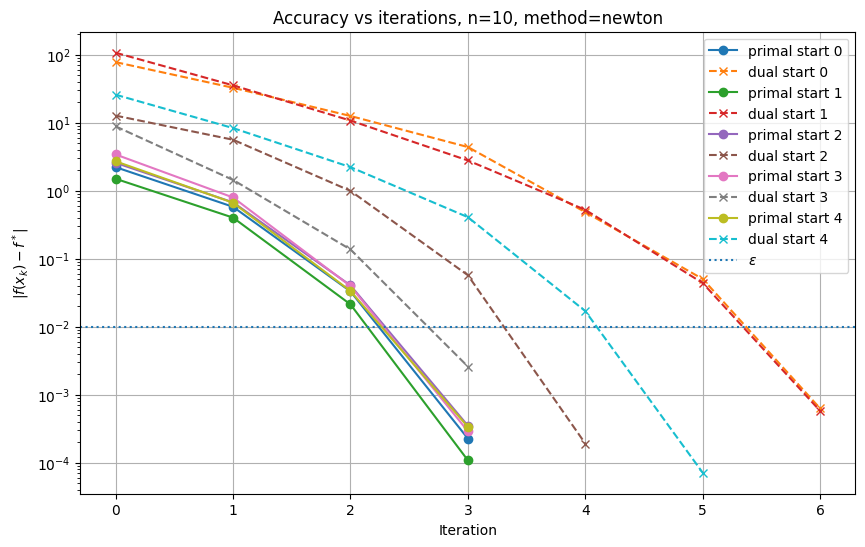

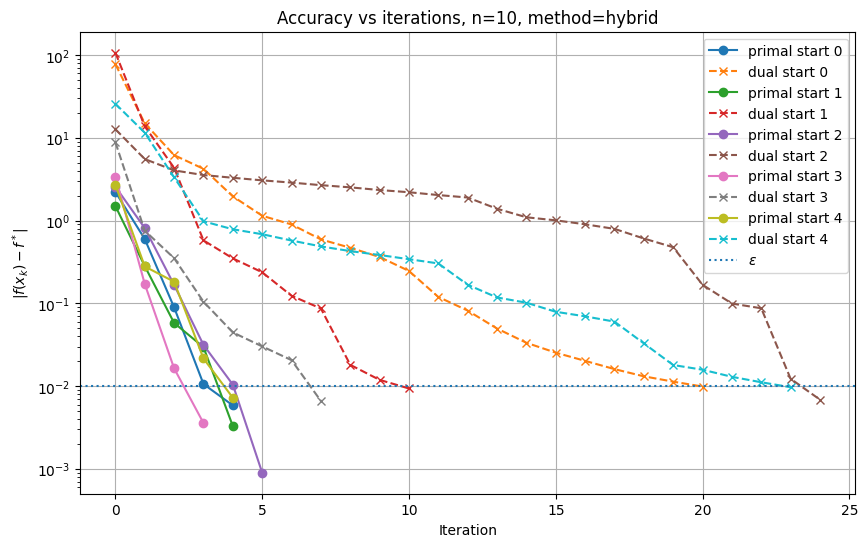

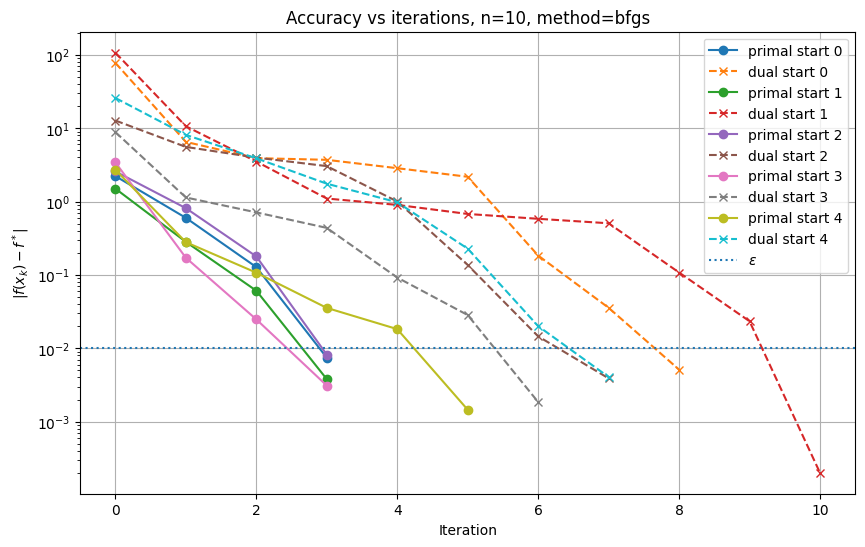

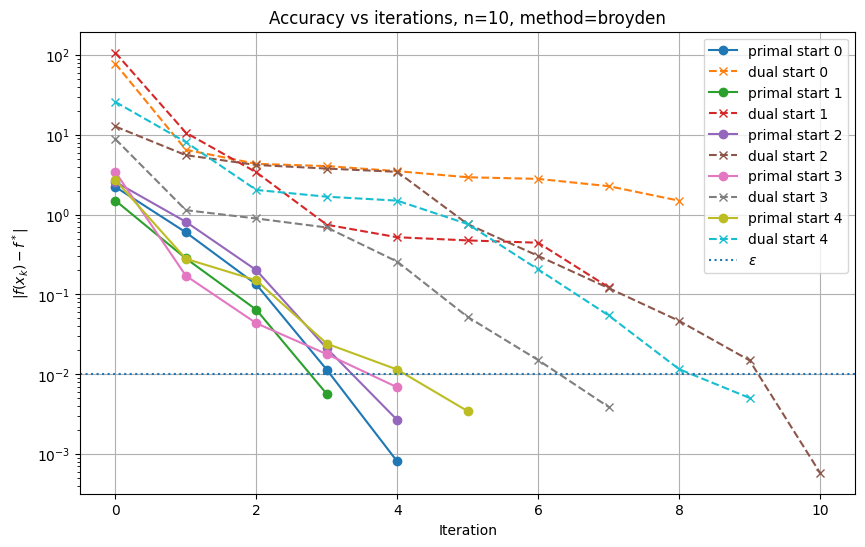

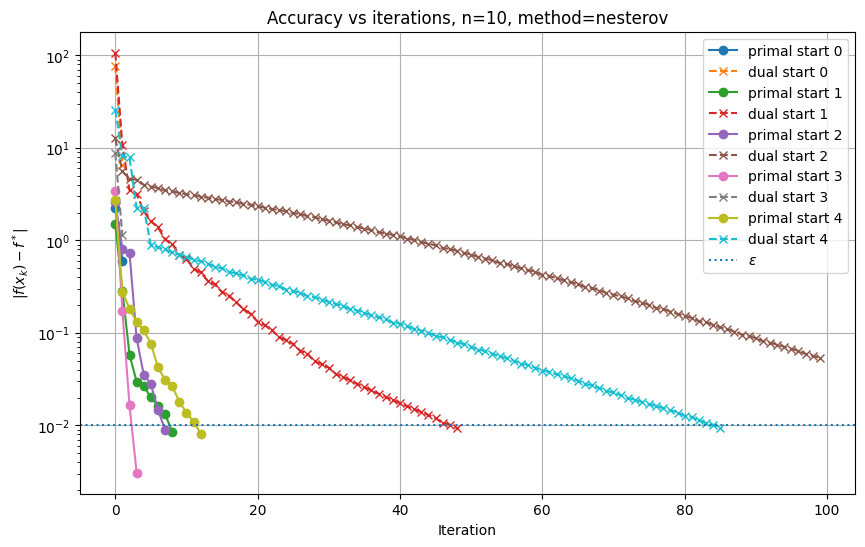

In [256]:
plot_accuracy_for_n10(df_all, "newton")
plot_accuracy_for_n10(df_all, "hybrid")
plot_accuracy_for_n10(df_all, "bfgs")
plot_accuracy_for_n10(df_all, "broyden")
plot_accuracy_for_n10(df_all, "nesterov")

1. Демпфированный метод Ньютона
- Для прямой задачи метод достигает требуемой точности за 2-3 итерации практически для всех начальных точек.
- Для двойственной задачи требуется больше итераций - примерно 3-6.
- После нескольких шагов ошибка уменьшается очень резко.
- Вблизи оптимума возникает квадратичная скорость сходимости, поэтому ошибка падает очень быстро.

2. Комбинированный метод (градиентный спуск + Ньютон)


### Среднее время и среднее число итераций для каждого n

In [257]:
summary_by_n = df_all.groupby(["method", "n"]).agg({
    "primal_iters": "mean",
    "dual_iters": "mean",
    "primal_time": "mean",
    "dual_time": "mean",
    "primal_success": "mean",
    "dual_success": "mean",
    "primal_final_error": "mean",
    "dual_final_error": "mean",
}).reset_index()

summary_by_n

,method,n,primal_iters,dual_iters,primal_time,dual_time,primal_success,dual_success,primal_final_error,dual_final_error
0,bfgs,10,3.40,6.96,0.001852,0.002701,1.00,1.00,0.004158,2.792369e-03
1,bfgs,20,4.52,16.56,0.002857,0.007965,1.00,1.00,0.005417,4.677266e-03
2,bfgs,30,4.68,26.12,0.002697,0.012307,1.00,1.00,0.005178,3.970434e-03
3,bfgs,40,6.68,37.28,0.004119,0.017781,1.00,1.00,0.004746,5.091808e-03
4,bfgs,50,6.80,53.68,0.004436,0.024526,1.00,1.00,0.005602,5.696084e-03
5,bfgs,60,7.88,73.36,0.005023,0.034522,1.00,0.96,0.005988,3.350132e+08
6,bfgs,70,7.88,82.36,0.004976,0.041182,1.00,0.96,0.005490,1.345465e+07
7,bfgs,80,7.64,134.28,0.005352,0.066930,1.00,0.96,0.005111,7.534500e+07
8,bfgs,90,9.20,122.64,0.006887,0.063722,1.00,0.80,0.004865,8.440951e+08
9,bfgs,100,8.24,139.64,0.006230,0.076796,1.00,0.56,0.005567,9.724031e+09


In [258]:
def plot_metric_by_n(summary, metric, ylabel):
    plt.figure(figsize=(10, 6))

    for method in summary["method"].unique():
        data = summary[summary["method"] == method]
        plt.plot(data["n"], data[metric], marker="o", label=method)

    plt.xlabel("n")
    plt.ylabel(ylabel)
    plt.title(ylabel + " by n")
    plt.grid(True)
    plt.legend()
    plt.show()

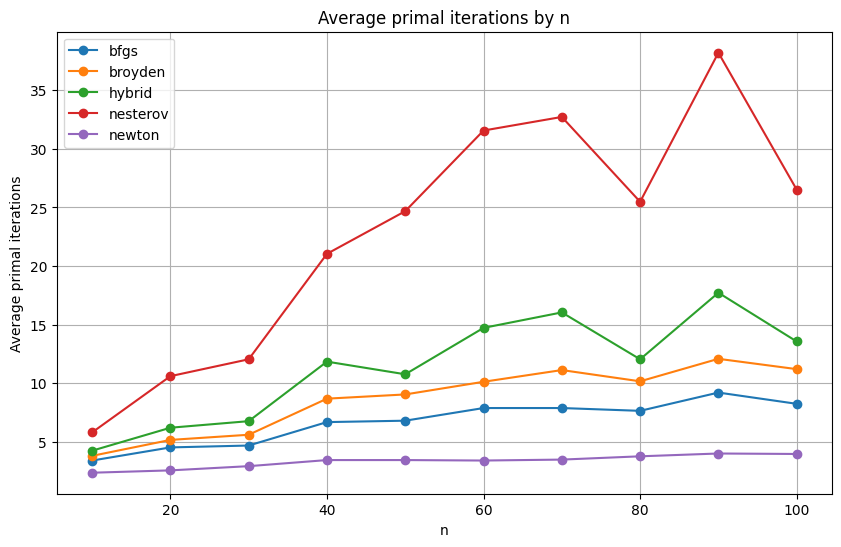

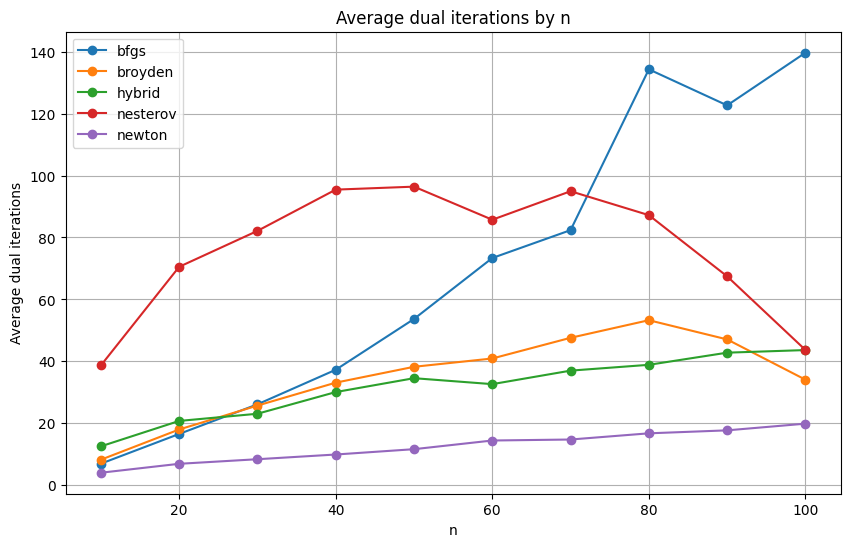

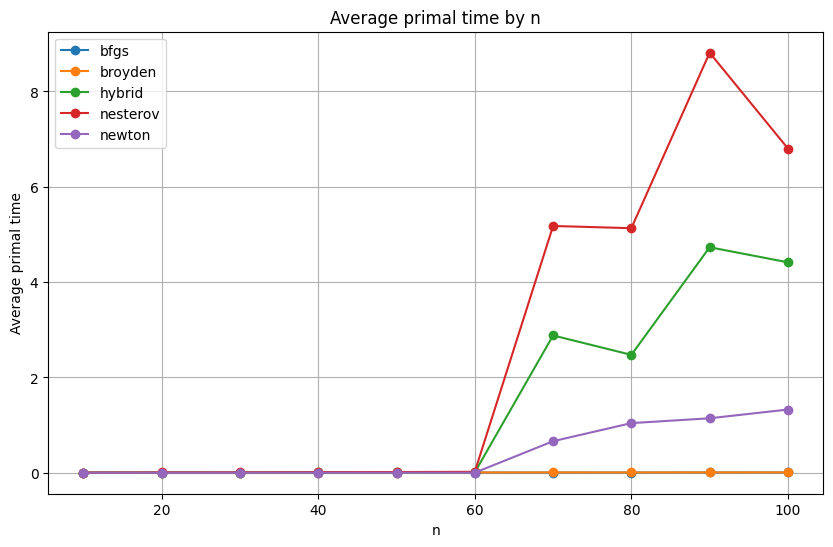

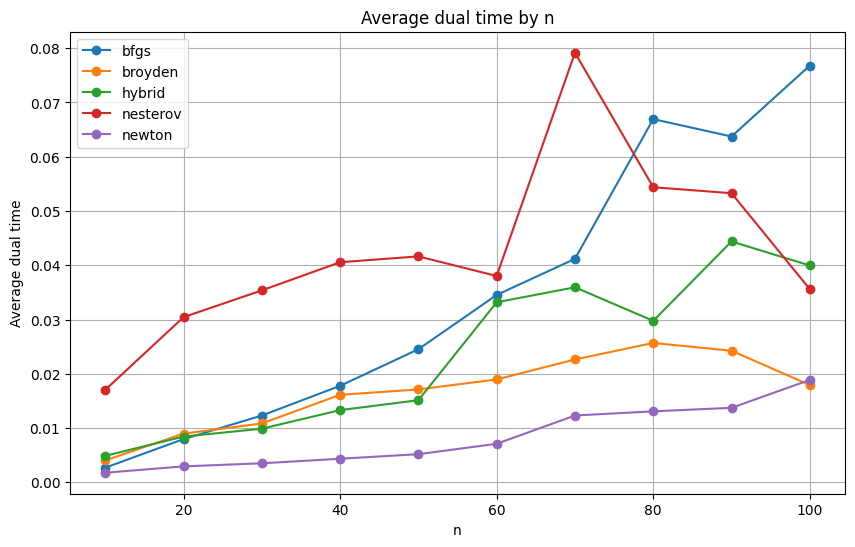

In [259]:
plot_metric_by_n(summary_by_n, "primal_iters", "Average primal iterations")
plot_metric_by_n(summary_by_n, "dual_iters", "Average dual iterations")
plot_metric_by_n(summary_by_n, "primal_time", "Average primal time")
plot_metric_by_n(summary_by_n, "dual_time", "Average dual time")

### Сравнительный анализ

In [260]:
qn_comparison = df_all[df_all["method"].isin(["bfgs", "broyden"])].groupby("method").agg({
    "primal_iters": "mean",
    "dual_iters": "mean",
    "primal_time": "mean",
    "dual_time": "mean",
    "primal_success": "mean",
    "dual_success": "mean",
}).reset_index()

qn_comparison

,method,primal_iters,dual_iters,primal_time,dual_time,primal_success,dual_success
0,bfgs,6.692,69.288,0.004443,0.034843,1.0,0.924
1,broyden,8.696,34.628,0.005368,0.016654,1.0,0.172


In [261]:
best_qn = "broyden"

In [262]:
methods_for_comparison = ["newton", "hybrid", best_qn, "nesterov"]

comparison = df_all[df_all["method"].isin(methods_for_comparison)].groupby("method").agg({
    "primal_iters": "mean",
    "dual_iters": "mean",
    "primal_time": "mean",
    "dual_time": "mean",
    "primal_success": "mean",
    "dual_success": "mean",
    "primal_final_error": "mean",
    "dual_final_error": "mean",
}).reset_index()

comparison

,method,primal_iters,dual_iters,primal_time,dual_time,primal_success,dual_success,primal_final_error,dual_final_error
0,broyden,8.696,34.628,0.005368,0.016654,1.000,0.172,0.005579,1.099196e+09
1,hybrid,11.388,31.600,1.453394,0.023483,1.000,1.000,0.006977,7.201982e-03
2,nesterov,22.864,76.212,2.598958,0.042545,0.964,0.280,0.019725,1.099717e+09
3,newton,3.332,12.448,0.418456,0.008284,1.000,1.000,0.003120,1.613927e-03


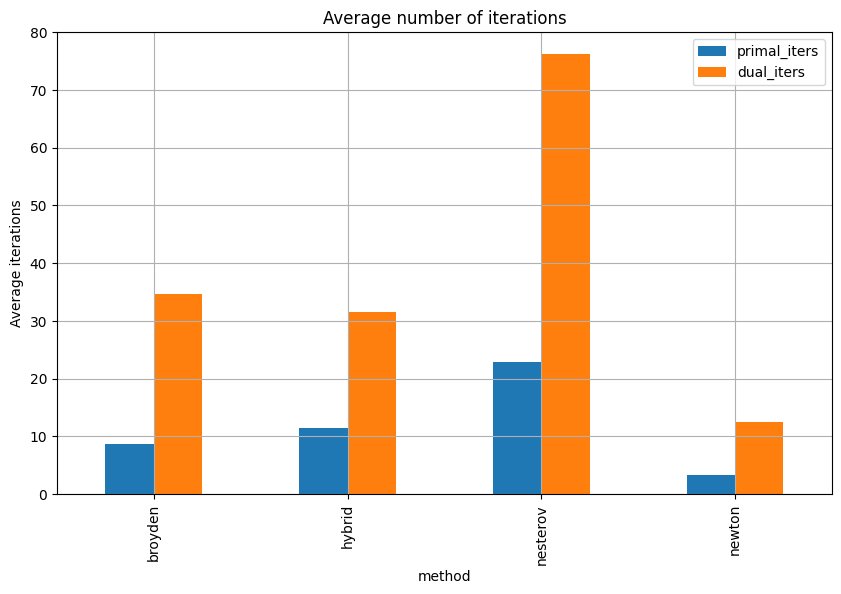

In [263]:
comparison.plot(
    x="method",
    y=["primal_iters", "dual_iters"],
    kind="bar",
    figsize=(10, 6),
)

plt.ylabel("Average iterations")
plt.title("Average number of iterations")
plt.grid(True)
plt.show()

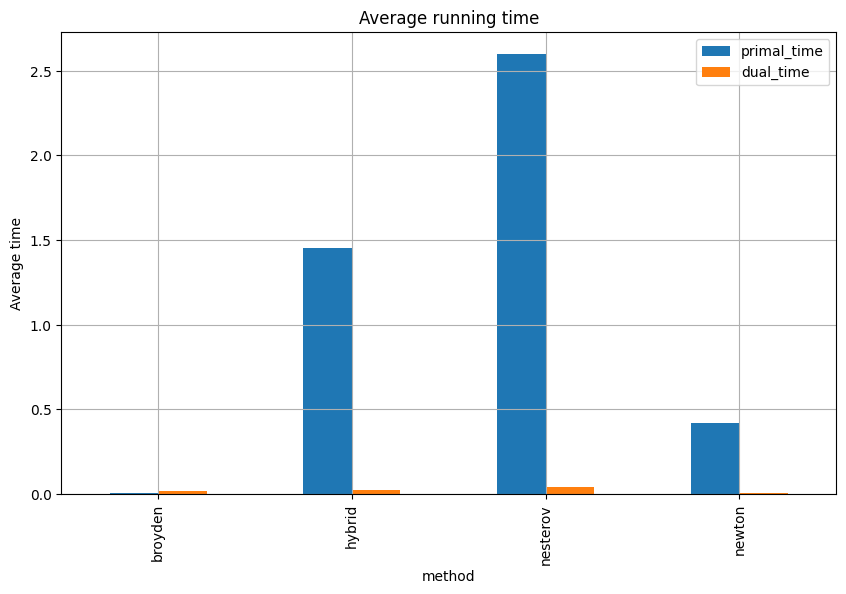

In [264]:
comparison.plot(
    x="method",
    y=["primal_time", "dual_time"],
    kind="bar",
    figsize=(10, 6),
)

plt.ylabel("Average time")
plt.title("Average running time")
plt.grid(True)
plt.show()